In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [3]:
query = select(Feedback.json, Feedback.datetime).filter(
        Feedback.key_name == 'vampire_subclasses',
        Feedback.datetime >= datetime(2023, 7, 1))
df = pd.read_sql_query(query, session.connection())

In [4]:
def vampire_subclasses(row):
    return {subclass: count for subclass, count in row['data'].items() if subclass != "ancient"}

In [5]:
df = df.join(pd.json_normalize(df.json.map(vampire_subclasses))).drop(['json'], axis=1)
df['dt'] = pd.to_datetime(df.datetime.dt.year.astype(str) + df.datetime.dt.month.astype(str), format='%Y%m')
df.drop(['datetime'], inplace=True, axis=1)

In [6]:
summed = df.groupby(['dt']).sum().astype(int)

In [7]:
cols = ['umbrae', 'gargantua', 'hemomancer', 'dantalion']
summed[cols] = summed[cols].div(summed[cols].sum(axis=1), axis=0).multiply(100)

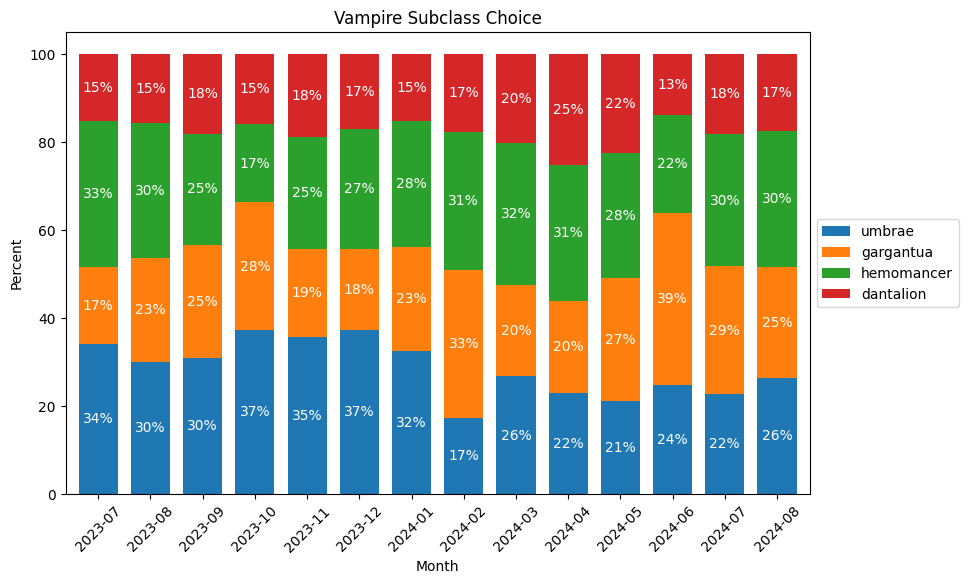

In [8]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

plot = summed.plot(kind='bar', stacked=True, ax=ax, width=0.75)
for c in ax.containers:
    labels = [f"{int(v.get_height())}%" if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white')
ax.set_xticklabels([x.strftime("%Y-%m") for x in summed.index], rotation=45)
plt.title("Vampire Subclass Choice")
ax.set_xlabel('Month')
ax.set_ylabel('Percent')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('vampire_subclass_percentage.png')

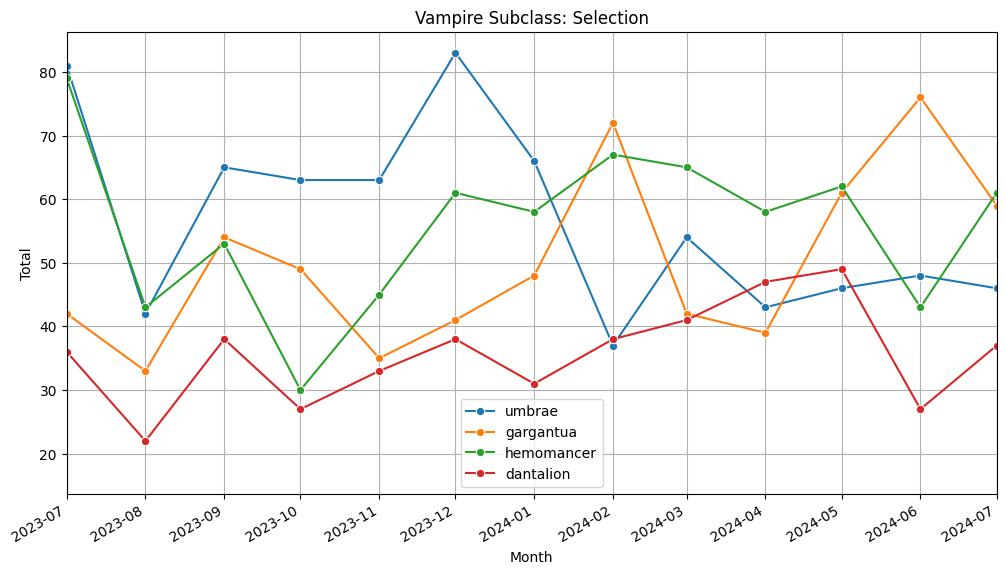

In [30]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
plot = sns.lineplot(
    data=df.groupby(['dt']).sum().astype(int),
    marker='o',
    linestyle='solid',
    dashes=False,
)
plot.set(xlim=(date(2023, 7, 1), date(2024, 7, 1)))
plot.set(title='Vampire Subclass: Selection')
plot.set(xlabel='Month', ylabel='Total')
months = mdates.MonthLocator(interval=1) 
ax.xaxis.set_major_locator(months)

for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax.grid()

plt.savefig('vampire_subclass_selection.png')

In [51]:
def json_to_series(text):
    keys, values = zip(*[item for item in text['data'].items()])
    return pd.Series(values, index=keys)

query = select(Feedback.json).filter(
    Feedback.key_name == 'vampire_success',
    Feedback.datetime >= datetime(2023, 7, 1),
)

df = pd.read_sql_query(query, session.connection())
df = pd.concat([df, df['json'].apply(json_to_series)], axis=1).drop(['json'], axis=1)

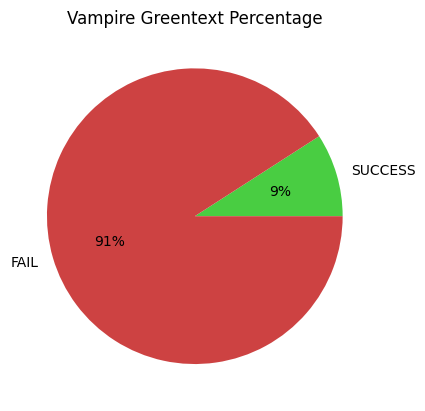

In [54]:
df[['SUCCESS', 'FAIL']].sum().astype(int).plot(kind='pie', autopct="%1.0f%%", colors=["#49cd42", "#cd4242"])
plt.title("Vampire Greentext Percentage")
plt.savefig('vamp_redtext.png')

In [61]:
query = select(Feedback.json).filter(
    or_(
        Feedback.key_name=='vampire_success',
        Feedback.key_name=='changeling_success',
        Feedback.key_name=='traitor_success'
    ),
    Feedback.datetime >= datetime(2023, 7, 1),
)

df = pd.read_sql_query(query, session.connection())
df = pd.concat([df, df['json'].apply(json_to_series)], axis=1)

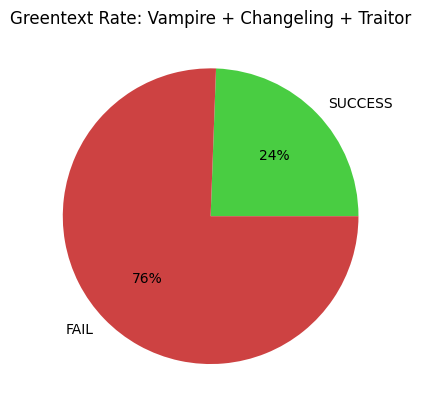

In [62]:
df[['SUCCESS', 'FAIL']].sum().astype(int).plot(kind='pie', autopct="%1.0f%%", colors=["#49cd42", "#cd4242"])
plt.title("Greentext Rate: Vampire + Changeling + Traitor")
plt.savefig('bigthree_redtext.png')